In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import numpy as np

In [45]:
mvp = pd.read_csv('mvp_awards.csv')
stats = pd.read_csv('stats.csv')
players = pd.read_csv('players.csv')
players = players.rename(columns={'id': 'player_id'})

In [46]:
best_50_2019 = stats[stats['season_id'] == 1].sort_values(by = 'Points' ,ascending = False).head(50)[['player_id','Points']]
best_50_2020 = stats[stats['season_id'] == 2].sort_values(by = 'Points' ,ascending = False).head(50)[['player_id','Points']]
best_50_2021 = stats[stats['season_id'] == 3].sort_values(by = 'Points' ,ascending = False).head(50)[['player_id','Points']]
best_50_2022 = stats[stats['season_id'] == 4].sort_values(by = 'Points' ,ascending = False).head(50)[['player_id','Points']]
best_50_2023 = stats[stats['season_id'] == 5].sort_values(by = 'Points' ,ascending = False).head(50)[['player_id','Points']]

merged_df = pd.concat([best_50_2019, best_50_2020, best_50_2021, best_50_2022, best_50_2023]).drop_duplicates(subset='player_id')
merged_df

,player_id,Points
0,105,2335
72,64,2335
62,59,2335
66,60,2335
68,16,2335
...,...,...
323,24,1804
337,189,1522
338,186,1509
340,43,1486


In [7]:
height_bestp = merged_df.merge(players[['player_id', 'height']], on='player_id')
height_bestp

,player_id,Points,height
0,105,2335,196
1,64,2335,185
2,59,2335,198
3,60,2335,208
4,16,2335,213
...,...,...,...
147,24,1804,208
148,189,1522,221
149,186,1509,196
150,43,1486,208


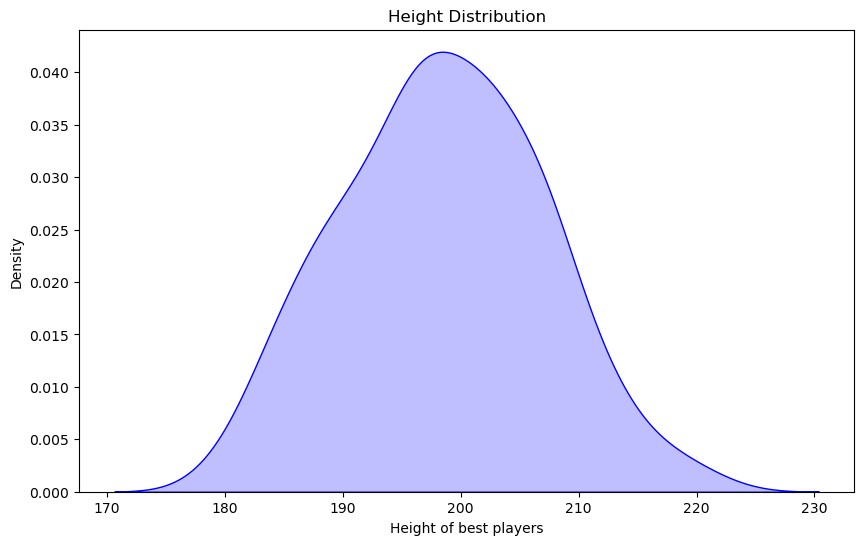

In [8]:
plt.figure(figsize=(10, 6))
sns.kdeplot(height_bestp['height'], fill=True, color='blue')
plt.title('Height Distribution')
plt.xlabel('Height of best players')
plt.ylabel('Density')
plt.show()

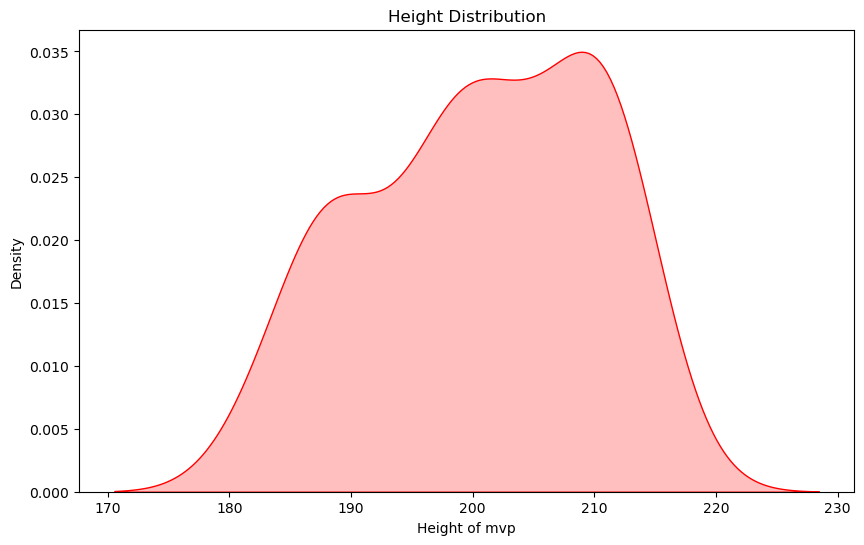

In [9]:
height_mvp = mvp.merge(players[['player_id', 'height']], on='player_id')[['player_id', 'height']]
plt.figure(figsize=(10, 6))
sns.kdeplot(height_mvp['height'], fill=True, color='red')
plt.title('Height Distribution')
plt.xlabel('Height of mvp')
plt.ylabel('Density')
plt.show()

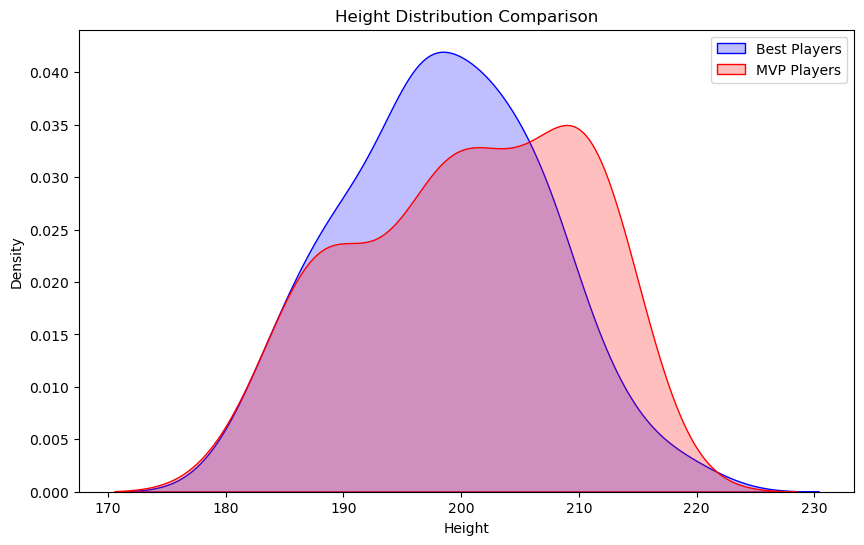

In [10]:
plt.figure(figsize=(10, 6))
sns.kdeplot(height_bestp['height'], fill=True, color='blue', label='Best Players')

sns.kdeplot(height_mvp['height'], fill=True, color='red', label='MVP Winners')

plt.title('Height Distribution Comparison')
plt.xlabel('Height')
plt.ylabel('Density')
plt.legend()

plt.show()


In [33]:
#For best players:
# Calculate mean (average value)
mean_bestp = height_bestp['height'].mean()

# Calculate range (max - min)
range_bestp = height_bestp['height'].max() - height_bestp['height'].min()

# Calculate quartiles (Q1, Q2/Median, Q3)
q1_b = np.percentile(height_bestp['height'], 25) 
q2_b = np.percentile(height_bestp['height'], 50)  
q3_b = np.percentile(height_bestp['height'], 75)  

# Calculate mode (most frequent value)
try:
    mode_bestp = stats.mode(height_bestp['height'])
except stats.StatisticsError:
    mode_bestp = "No unique mode"

# Print results in a structured format
print(f"Mean: {mean_bestp}")
print(f"Range: {range_bestp}")
print(f"Mode: {mode_bestp}")
print(f"Q1: {q1_b}, Median (Q2): {q2_b}, Q3: {q3_b}")

Mean: 198.46052631578948
Range: 41
Mode: 196
Q1: 193.0, Median (Q2): 198.0, Q3: 203.75


In [47]:
#For mvp winners:
# Calculate mean (average value)
mean_mvp = height_mvp['height'].mean()

# Calculate range (max - min)
range_mvp = height_mvp['height'].max() - height_mvp['height'].min()

# Calculate quartiles (Q1, Q2/Median, Q3)
q1_m = np.percentile(height_mvp['height'], 25)  # First quartile (25th percentile)
q2_m = np.percentile(height_mvp['height'], 50)  # Median (50th percentile)
q3_m = np.percentile(height_mvp['height'], 75)  # Third quartile (75th percentile)

# finding the most frequent value (peak)
peak_counts = height_mvp['height'].value_counts()
peak_mvp = peak_counts[peak_counts == peak_counts.max()].index.tolist()  # Get all peaks


print(f"Mean: {mean_mvp}")
print(f"Range: {range_mvp}")
print(f"Mode: {mode_mvp}")
print(f"Q1: {q1_m}, Median (Q2): {q2_m}, Q3: {q3_m}")
print(f"Peak(s): {peak_mvp}")

Mean: 200.59322033898306
Range: 33
Mode: 211
Q1: 193.0, Median (Q2): 201.0, Q3: 211.0
Peak(s): [211]


6


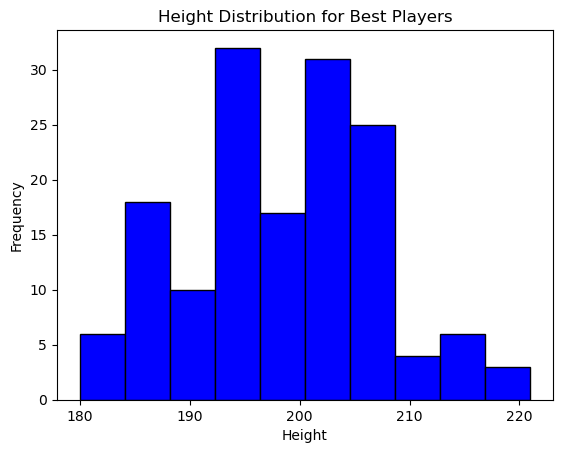

In [61]:
num_bins = int(np.log2(len(height_mvp['height'])) + 1)
print(num_bins)
plt.hist(height_bestp['height'], bins=10 , color = "blue", edgecolor="black")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Height Distribution for Best Players")
plt.show()

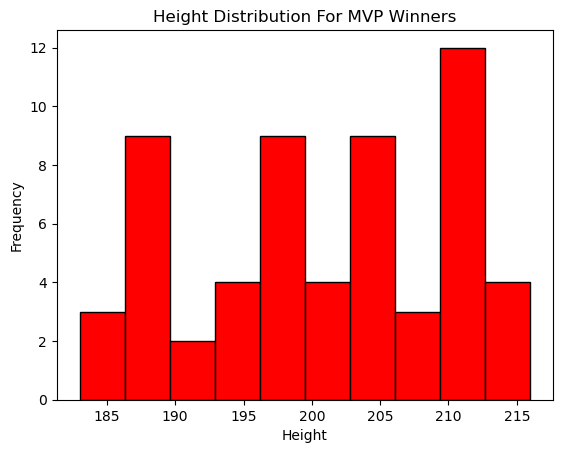

In [65]:
plt.hist(height_mvp['height'], bins=10 ,color = "red", edgecolor="black")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Height Distribution For MVP Winners")
plt.show()

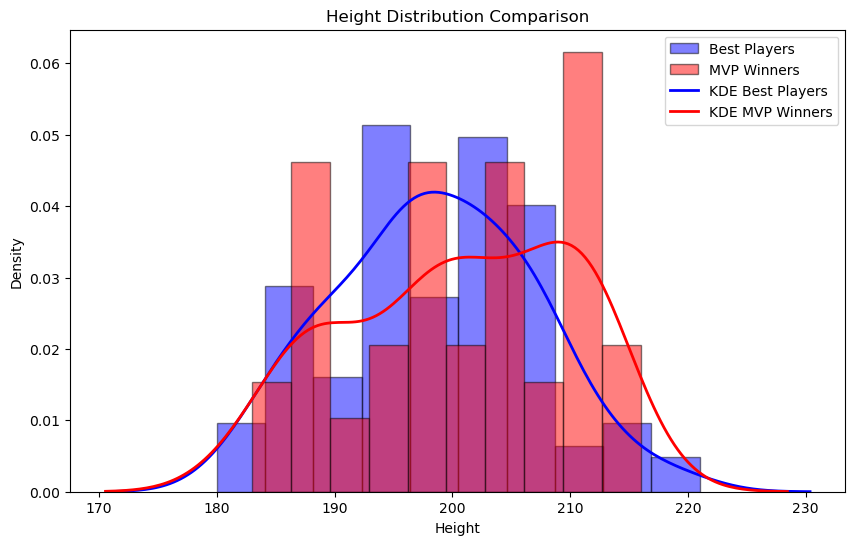

In [88]:
plt.figure(figsize=(10, 6))
plt.hist(height_bestp['height'], bins=10 , color = "blue", edgecolor="black",alpha=0.5, label='Best Players', density=True)

plt.hist(height_mvp['height'], bins=10 ,color = "red", edgecolor="black",alpha=0.5, label='MVP Winners', density=True)

sns.kdeplot(height_bestp['height'], color="blue", linewidth=2, label='KDE Best Players')
sns.kdeplot(height_mvp['height'], color="red", linewidth=2, label='KDE MVP Winners')

plt.title('Height Distribution Comparison')
plt.xlabel('Height')
plt.ylabel('Density')
plt.legend()

plt.show()

In [90]:
#just being curuios about the ways to calculate bins
# data = height_mvp['height'] 
# iqr = np.percentile(data, 75) - np.percentile(data, 25)  # Q3 - Q1 (Interquartile Range)
# bin_width = 2 * iqr * (len(data) ** (-1/3))  # Freedman-Diaconis Formula
# num_bins = int((data.max() - data.min()) / bin_width)  # Total range divided by bin width
# num_bins

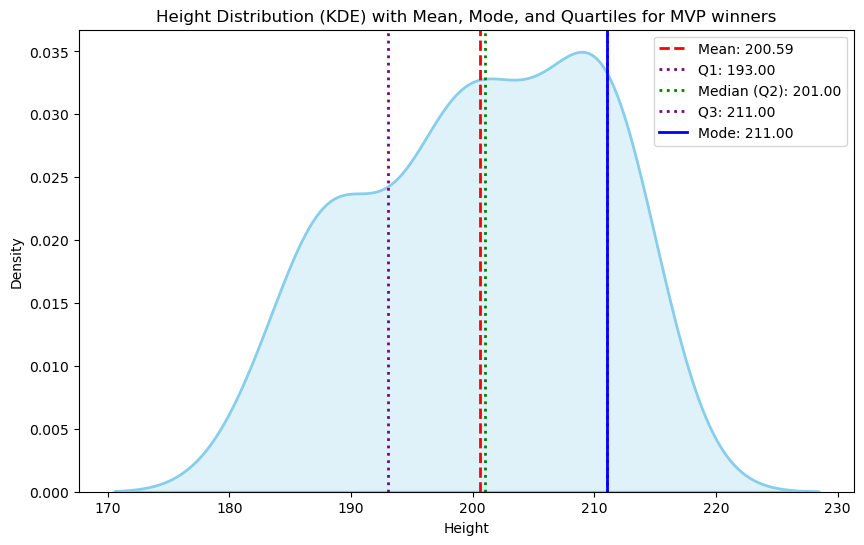

In [71]:
plt.figure(figsize=(10, 6))
sns.kdeplot(height_mvp['height'], fill =True, color="skyblue", linewidth=2)

# Overlay Mean
plt.axvline(mean_mvp, color='red', linestyle='dashed', linewidth=2, label=f"Mean: {mean_mvp:.2f}")

# Overlay Quartiles
plt.axvline(q1_m, color='purple', linestyle='dotted', linewidth=2, label=f"Q1: {q1_m:.2f}")
plt.axvline(q2_m, color='green', linestyle='dotted', linewidth=2, label=f"Median (Q2): {q2_m:.2f}")
plt.axvline(q3_m, color='purple', linestyle='dotted', linewidth=2, label=f"Q3: {q3_m:.2f}")

# Overlay Mode(s) / Peak(s)
for peak in peak_mvp:
    plt.axvline(peak, color='blue', linestyle='solid', linewidth=2, label=f"Mode: {peak:.2f}")

plt.xlabel("Height")
plt.ylabel("Density")
plt.title("Height Distribution (KDE) with Mean, Mode, and Quartiles for MVP winners")
plt.legend()
plt.show()


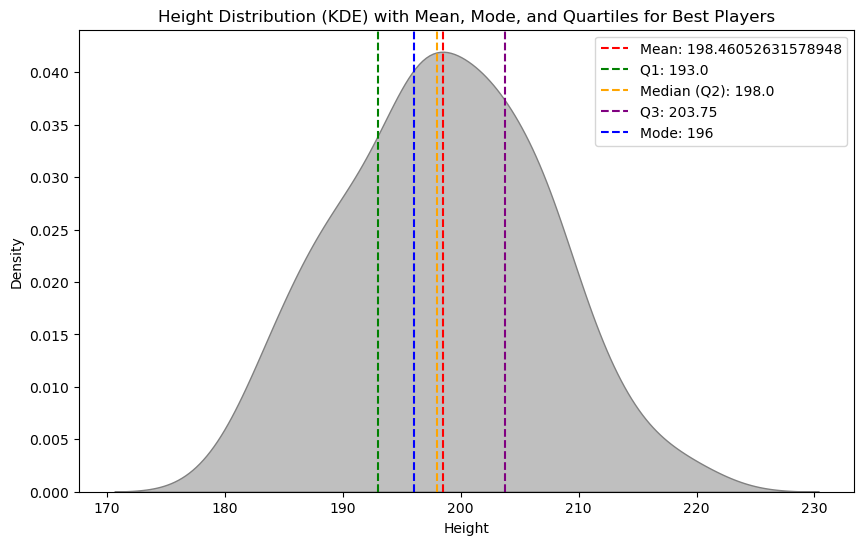

In [89]:
plt.figure(figsize=(10, 6))
sns.kdeplot(height_bestp['height'], fill=True, color='grey', alpha=0.5)

# Overlay statistical lines
plt.axvline(mean_bestp, color='red', linestyle='--', label=f'Mean: {mean_bestp}')
plt.axvline(q1_b, color='green', linestyle='--', label=f'Q1: {q1_b}')
plt.axvline(q2_b, color='orange', linestyle='--', label=f'Median (Q2): {q2_b}')
plt.axvline(q3_b, color='purple', linestyle='--', label=f'Q3: {q3_b}')
plt.axvline(mode_bestp, color='blue', linestyle='--', label=f'Mode: {mode_bestp}')

plt.title('Height Distribution (KDE) with Mean, Mode, and Quartiles for Best Players')
plt.xlabel('Height')
plt.ylabel('Density')
plt.legend()
plt.show()

# Explanation of the Code:
# KDE Plot: The sns.kdeplot() function is used to plot the Kernel Density Estimation (KDE) for the height data.
# Overlay Lines: Using plt.axvline(), vertical lines are added to represent the mean, quartiles (Q1, Q2, Q3), and mode. Each line is assigned a different color and labeled accordingly.
# Legend: plt.legend() displays the labels for each line on the plot.
# Labels: The plot includes a title and axis labels for clarity.
# This will give us a KDE plot with the mean, quartiles, and mode overlaid as vertical lines for clear visualization.

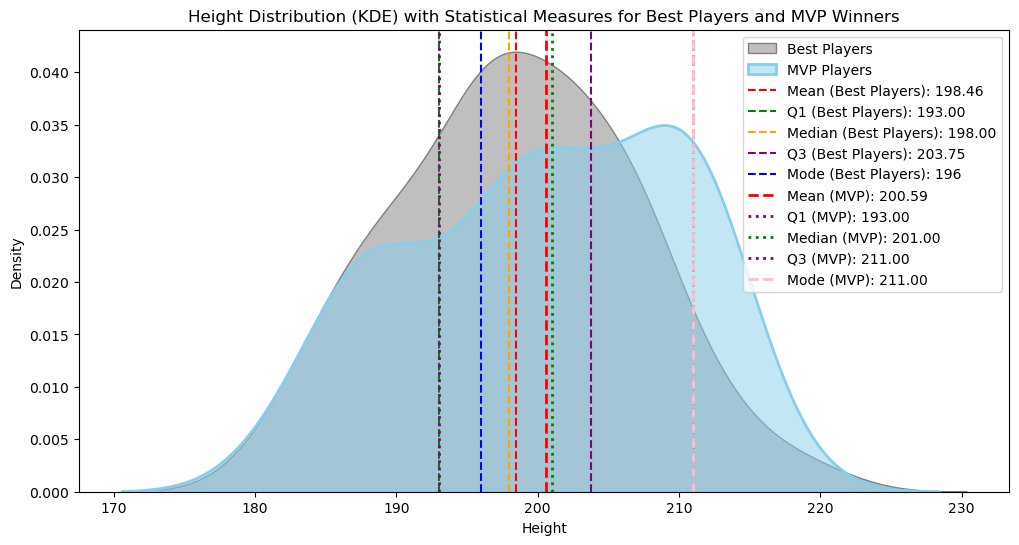

In [77]:
# Plot both KDEs on the same figure
plt.figure(figsize=(12, 6))

# KDE for Best Players
sns.kdeplot(height_bestp['height'], fill=True, color='grey', alpha=0.5, label="Best Players")

# KDE for MVP Players
sns.kdeplot(height_mvp['height'], fill=True, color='skyblue', alpha=0.5, linewidth=2, label="MVP Players")

# Overlay statistical lines for Best Players
plt.axvline(mean_bestp, color='red', linestyle='--', label=f'Mean (Best Players): {mean_bestp:.2f}')
plt.axvline(q1_b, color='green', linestyle='--', label=f'Q1 (Best Players): {q1_b:.2f}')
plt.axvline(q2_b, color='orange', linestyle='--', label=f'Median (Best Players): {q2_b:.2f}')
plt.axvline(q3_b, color='purple', linestyle='--', label=f'Q3 (Best Players): {q3_b:.2f}')
plt.axvline(mode_bestp, color='blue', linestyle='--', label=f'Mode (Best Players): {mode_bestp}')

# Overlay statistical lines for MVP Players
plt.axvline(mean_mvp, color='red', linestyle='dashed', linewidth=2, label=f"Mean (MVP): {mean_mvp:.2f}")
plt.axvline(q1_m, color='purple', linestyle='dotted', linewidth=2, label=f"Q1 (MVP): {q1_m:.2f}")
plt.axvline(q2_m, color='green', linestyle='dotted', linewidth=2, label=f"Median (MVP): {q2_m:.2f}")
plt.axvline(q3_m, color='purple', linestyle='dotted', linewidth=2, label=f"Q3 (MVP): {q3_m:.2f}")

# Overlay Mode(s) / Peak(s) for MVP Players
for peak in peak_mvp:
    plt.axvline(peak, color='pink', linestyle='--', linewidth=2, label=f"Mode (MVP): {peak:.2f}")

plt.xlabel("Height")
plt.ylabel("Density")
plt.title("Height Distribution (KDE) with Statistical Measures for Best Players and MVP Winners")
plt.legend()

plt.show()
